# How well do jobs and skills pay for Data Analysts?

## Methodology

1. Evaluate median salary for top 6 data jobs
2. Find median salary per skill for Data Analysts
3. Visualize for highest paying skills and most demanded skills

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

/opt/anaconda3/envs/CursoLukeB/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Select country and drop NA values

df_ES = df[(df['job_country'] == 'Spain')].dropna(subset=['salary_year_avg']).copy()


In [3]:
# Get the top 6 Job titles
job_titles = df_ES['job_title_short'].value_counts().index[:6].tolist()
job_titles

['Data Engineer',
 'Data Analyst',
 'Data Scientist',
 'Machine Learning Engineer',
 'Senior Data Engineer',
 'Senior Data Analyst']

In [4]:
# Filter de Data Frame for only the top 6 job roles
df_ES_top = df_ES[df_ES['job_title_short'].isin(job_titles)]

In [5]:
# Find the median salary for all the salaries to order them by it

job_order = df_ES_top.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

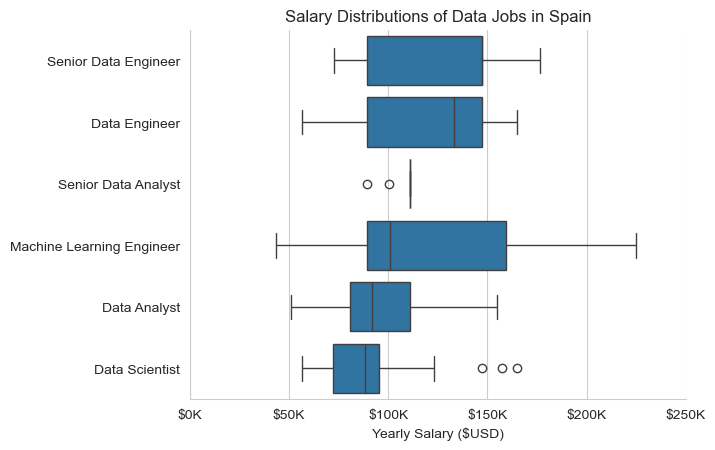

In [6]:
# Boxplot
sns.boxplot(data=df_ES_top, x='salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme(style='ticks')
sns.despine()

plt.title('Salary Distributions of Data Jobs in Spain')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('')
plt.xlim(0, 250000)
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

## Investigate Median Salary Vs Skill for Data Analysts

In [7]:
# Filter de df for Data Analysts in Spain only
df_DA_ES = df[(df['job_country'] == 'Spain') & (df['job_title_short'] == 'Data Analyst')].copy()

# Drop NA values for their salaries
df_DA_ES = df_DA_ES.dropna(subset=['salary_year_avg'])

In [9]:
# Explode the job skills column
df_DA_ES = df_DA_ES.explode('job_skills')

In [18]:
# Group by job skills to find the top paying skills

df_DA_ES_top_pay = df_DA_ES.groupby(by='job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)
df_DA_ES_top_pay = df_DA_ES_top_pay.head(10)
df_DA_ES_top_pay

,count,median
job_skills,,
smartsheet,1,155000.0
sap,1,118640.0
npm,1,111202.0
node.js,1,111202.0
react,1,111202.0
angular,1,111202.0
scikit-learn,1,111175.0
looker,4,111175.0
numpy,2,111175.0


In [23]:
# Group by the most popular skills for Data Analysts
df_DA_ES_top_skills = df_DA_ES.groupby(by='job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

# Now sort by the hights median salary of the most demanded skills
df_DA_ES_top_skills = df_DA_ES_top_skills.head(10)
df_DA_ES_top_skills = df_DA_ES_top_skills.sort_values(by='median')
df_DA_ES_top_skills


,count,median
job_skills,,
excel,5,72900.0
power bi,4,73352.0
sql,17,89100.0
snowflake,3,89100.0
python,14,98500.0
tableau,9,98500.0
airflow,3,98500.0
jupyter,3,105000.0
pandas,4,108087.5


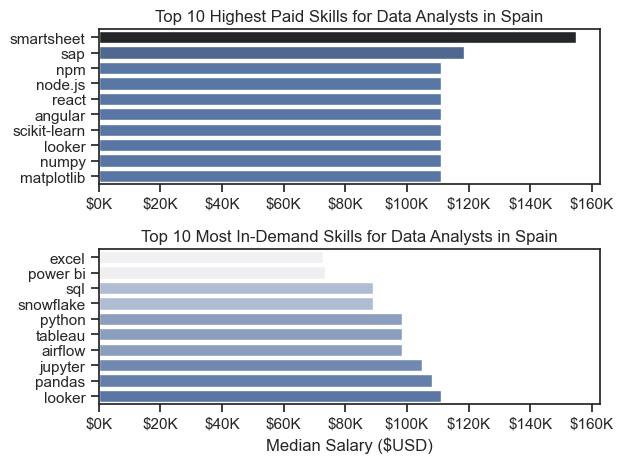

In [25]:
# Plot
fig, ax = plt.subplots(2, 1)

# Top 10 Highest Paid Skills for Data Analysts
sns.barplot(data=df_DA_ES_top_pay, x='median', y=df_DA_ES_top_pay.index, hue='median', ax=ax[0], palette='dark:b_r')
ax[0].legend().remove()
# original code:
# df_DA_ES_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts in Spain')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


# Top 10 Most In-Demand Skills for Data Analysts'
sns.barplot(data=df_DA_ES_top_skills, x='median', y=df_DA_ES_top_skills.index, hue='median', ax=ax[1], palette='light:b')
ax[1].legend().remove()
# original code:
# df_DA_ES_top_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts in Spain')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].set_xlim(ax[0].get_xlim())  # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

sns.set_theme(style='ticks')
plt.tight_layout()
plt.show()